In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "syn1_Friedman_pt_mtmh"


In [2]:
import numpy as np

# Friedman (1991): 10 predictors, only the first 5 are relevant
rng = np.random.default_rng(42)
n_samples = 2000
noise_std = 1.0

X = rng.uniform(0.0, 1.0, size=(n_samples, 10)).astype(float)
eps = rng.normal(0.0, noise_std, size=n_samples)
y = (
    10.0 * np.sin(np.pi * X[:, 0] * X[:, 1])
    + 20.0 * (X[:, 2] - 0.5) ** 2
    + 10.0 * X[:, 3]
    + 5.0 * X[:, 4]
    + eps
)
y = np.asarray(y).reshape(-1)

X.shape, y.shape

((2000, 10), (2000,))

In [3]:
from experiment import run_parallel_experiments

ndpost = 2000
nskip = 0
n_trees = 100

# You can scale these up for final experiments
n_runs = 5
n_chains = 4
n_jobs = -2

default_proposal_probs = {"grow": 0.4, "prune": 0.4, "change": 0.1, "swap": 0.1}
mtmh_proposal_probs = {"multi_grow": 0.4, "multi_prune": 0.4, "multi_change": 0.1, "multi_swap": 0.1}

results = run_parallel_experiments(
    X=X,
    y=y,
    ndpost=ndpost,
    nskip=nskip,
    n_trees=n_trees,
    notebook=notebook,
    n_runs=n_runs,
    n_chains=n_chains,
    n_jobs=n_jobs,
    store_preds=True,
    n_test_points=100,
    swap_interval=50,
    ladder_target_rate=0.4,
    ladder_max_rounds=10,
    ladder_ndpost=500,
    ladder_nskip=100,
    ladder_repeats=3,
    ladder_search_points=500,
    ladder_initial_temperatures=(1.0, 1000000.0),
    proposal_probs_default=default_proposal_probs,
    proposal_probs_mtmh=mtmh_proposal_probs,
    multi_tries=10,
    store_dir="store",
    progress_print=True,
 )

print(f"Finished. Stored CSV files under: {Path('store').resolve()}")

[RUN 0] start (1/5) | split_seed=42
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 1000000.0]
[LADDER] round 1/10: n_temps=2, mean_rates=[0.2]
[LADDER] round 2/10: n_temps=3, mean_rates=[0.9, 0.3]
[LADDER] round 3/10: n_temps=4, mean_rates=[0.9556, 0.9778, 0.2]
[LADDER] round 4/10: n_temps=5, mean_rates=[0.9833, 1.0, 0.9833, 0.15]
[LADDER] round 5/10: n_temps=6, mean_rates=[0.96, 0.9867, 1.0, 0.9467, 0.24]
[LADDER] round 6/10: n_temps=7, mean_rates=[0.9556, 0.9889, 0.9778, 0.9778, 0.9667, 0.2111]
[LADDER] round 7/10: n_temps=8, mean_rates=[0.8952, 0.9333, 0.981, 0.9714, 0.9619, 0.9333, 0.1238]
[LADDER] round 8/10: n_temps=9, mean_rates=[0.8583, 0.925, 0.9833, 0.9583, 0.9667, 0.975, 0.9, 0.1667]
[LADDER] round 9/10: n_temps=10, mean_rates=[0.8074, 0.8741, 0.9259, 0.963, 0.9704, 0.9407, 0.9185, 0.8889, 0.2222]
[LADDER] round 10/10: n_temps=11, mean_rates=[0.7467, 0.84, 0.84, 0.9, 0.9133, 0.92, 0.9133, 0.8933, 0.7467, 0.2467]
[LADDER] done: final n_

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 57.5min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 57.5min remaining: 57.5min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 57.6min finished


[RUN 0] done and saved to store
[RUN 1] start (2/5) | split_seed=43
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 1000000.0]
[LADDER] round 1/10: n_temps=2, mean_rates=[0.3333]
[LADDER] round 2/10: n_temps=3, mean_rates=[1.0, 0.2333]
[LADDER] round 3/10: n_temps=4, mean_rates=[1.0, 1.0, 0.0889]
[LADDER] round 4/10: n_temps=5, mean_rates=[1.0, 0.9833, 1.0, 0.1667]
[LADDER] round 5/10: n_temps=6, mean_rates=[1.0, 1.0, 1.0, 0.9733, 0.2]
[LADDER] round 6/10: n_temps=7, mean_rates=[0.9667, 0.9889, 0.9778, 0.9889, 0.9667, 0.1222]
[LADDER] round 7/10: n_temps=8, mean_rates=[0.8952, 0.9333, 0.9619, 1.0, 0.9905, 0.981, 0.1429]
[LADDER] round 8/10: n_temps=9, mean_rates=[0.825, 0.9167, 0.9583, 0.9583, 0.975, 0.9667, 0.9167, 0.075]
[LADDER] round 9/10: n_temps=10, mean_rates=[0.8741, 0.8593, 0.8963, 0.9481, 0.9778, 0.9704, 0.9333, 0.837, 0.1407]
[LADDER] round 10/10: n_temps=11, mean_rates=[0.7933, 0.8467, 0.8933, 0.92, 0.96, 0.9533, 0.9467, 0.9267, 0.8467

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 58.5min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 58.5min remaining: 58.5min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 58.7min finished


[RUN 1] done and saved to store
[RUN 2] start (3/5) | split_seed=44
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 1000000.0]
[LADDER] round 1/10: n_temps=2, mean_rates=[0.2667]
[LADDER] round 2/10: n_temps=3, mean_rates=[1.0, 0.2]
[LADDER] round 3/10: n_temps=4, mean_rates=[0.9333, 1.0, 0.1778]
[LADDER] round 4/10: n_temps=5, mean_rates=[0.9667, 0.9667, 0.95, 0.15]
[LADDER] round 5/10: n_temps=6, mean_rates=[0.96, 0.9867, 0.9733, 0.9333, 0.2133]
[LADDER] round 6/10: n_temps=7, mean_rates=[0.9667, 0.9778, 0.9778, 1.0, 0.9778, 0.2111]
[LADDER] round 7/10: n_temps=8, mean_rates=[0.9429, 0.981, 0.981, 0.9714, 0.9619, 0.9333, 0.1429]
[LADDER] round 8/10: n_temps=9, mean_rates=[0.875, 0.9167, 0.9333, 0.9833, 0.9833, 0.9417, 0.9333, 0.1833]
[LADDER] round 9/10: n_temps=10, mean_rates=[0.8593, 0.8741, 0.8963, 0.9481, 0.9556, 0.9333, 0.9407, 0.8444, 0.1407]
[LADDER] round 10/10: n_temps=11, mean_rates=[0.8067, 0.8933, 0.9, 0.9, 0.94, 0.9667, 0.92, 0.9533

...

[RUN 2] done and saved to store
[RUN 3] start (4/5) | split_seed=45
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 1000000.0]
[LADDER] round 1/10: n_temps=2, mean_rates=[0.2667]
[LADDER] round 2/10: n_temps=3, mean_rates=[0.9333, 0.1667]
[LADDER] round 3/10: n_temps=4, mean_rates=[0.9333, 1.0, 0.2222]
[LADDER] round 4/10: n_temps=5, mean_rates=[0.9833, 0.95, 0.9667, 0.1667]
[LADDER] round 5/10: n_temps=6, mean_rates=[0.9467, 0.9867, 1.0, 1.0, 0.16]
[LADDER] round 6/10: n_temps=7, mean_rates=[0.9889, 1.0, 0.9778, 0.9889, 0.9667, 0.1111]
[LADDER] round 7/10: n_temps=8, mean_rates=[0.9048, 0.9905, 0.9524, 0.981, 0.9714, 0.9619, 0.1714]
[LADDER] round 8/10: n_temps=9, mean_rates=[0.8917, 0.9167, 0.9333, 0.9833, 0.9917, 0.9333, 0.9083, 0.1333]
[LADDER] round 9/10: n_temps=10, mean_rates=[0.8222, 0.8963, 0.8889, 0.963, 0.9481, 0.9111, 0.9333, 0.9185, 0.1111]
[LADDER] round 10/10: n_temps=11, mean_rates=[0.7867, 0.84, 0.88, 0.8867, 0.94, 0.9333, 0.9467,

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 65.1min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 65.5min remaining: 65.5min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 65.7min finished


[RUN 3] done and saved to store
[RUN 4] start (5/5) | split_seed=46
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 1000000.0]
[LADDER] round 1/10: n_temps=2, mean_rates=[0.1333]
[LADDER] round 2/10: n_temps=3, mean_rates=[1.0, 0.3]
[LADDER] round 3/10: n_temps=4, mean_rates=[0.9111, 1.0, 0.2222]
[LADDER] round 4/10: n_temps=5, mean_rates=[0.9833, 1.0, 1.0, 0.15]
[LADDER] round 5/10: n_temps=6, mean_rates=[0.9867, 1.0, 0.96, 1.0, 0.2267]
[LADDER] round 6/10: n_temps=7, mean_rates=[0.9556, 0.9889, 1.0, 1.0, 0.9889, 0.1889]
[LADDER] round 7/10: n_temps=8, mean_rates=[0.8952, 0.9524, 0.9905, 0.9905, 0.9619, 0.9429, 0.1524]
[LADDER] round 8/10: n_temps=9, mean_rates=[0.825, 0.95, 0.95, 0.95, 0.975, 0.95, 0.8917, 0.1583]
[LADDER] round 9/10: n_temps=10, mean_rates=[0.8593, 0.8963, 0.9037, 0.963, 0.9259, 0.9556, 0.9481, 0.9037, 0.1852]
[LADDER] round 10/10: n_temps=11, mean_rates=[0.7933, 0.8333, 0.8933, 0.9, 0.9, 0.9733, 0.9533, 0.9133, 0.7733, 0.1933]

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 59.5min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 59.6min remaining: 59.6min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 59.7min finished


[RUN 4] done and saved to store
Finished. Stored CSV files under: C:\Users\ztykk\Phd\BART\bart-playground\diagnosis\pt+mtmh_2000\store


In [4]:
from IPython.display import display
import ast
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from tabpfn import TabPFNRegressor
import matplotlib.pyplot as plt
import numpy as np

comparison_specs = [
    ("default", "default", "tab:blue"),
    ("default_pt", "default_pt", "tab:orange"),
    ("mtmh", "mtmh", "tab:green"),
    ("mtmh_pt", "mtmh+pt", "tab:red"),
]

comparison_labels = {key: label for key, label, _ in comparison_specs}
comparison_colors = {key: color for key, _, color in comparison_specs}
comparison_colors_by_label = {label: color for key, label, color in comparison_specs}
comparison_colors_by_label["tabpfn"] = "tab:purple"
comparison_colors_by_label["y_test_sub"] = "black"

def ensure_point_by_sample(arr, n_points):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape={arr.shape}")
    if arr.shape[0] == n_points:
        return arr
    if arr.shape[1] == n_points:
        return arr.T
    raise ValueError(f"Could not align samples with n_points={n_points}, shape={arr.shape}")

def crps_from_samples(samples, y_true):
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)
    return term1 - term2

def _load_numeric_csv(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    original_shape = None
    if header.startswith("# original_shape="):
        original_shape = ast.literal_eval(header[len("# original_shape="):])
    data = np.loadtxt(file_path, delimiter=",", comments="#", skiprows=1)
    data = np.asarray(data)
    if original_shape is not None:
        return data.reshape(original_shape)
    return data

def load_results_from_store(store_root, notebook):
    metadata_files = sorted((store_root / "metadata").glob(f"{notebook}__run*.csv"))
    if not metadata_files:
        raise FileNotFoundError(f"No stored runs found for notebook={notebook} in {store_root}")

    results = []
    for metadata_file in metadata_files:
        run_id = int(metadata_file.stem.split("__run")[-1])
        run_tag = f"{notebook}__run{run_id:03d}"
        meta = pd.read_csv(metadata_file).set_index("key")["value"].to_dict()
        run_result = {
            "run_id": run_id,
            "split_seed": int(meta["split_seed"]),
            "subsample": {
                "X_test": _load_numeric_csv(store_root / "subsample_X_test" / f"{run_tag}__subsample_X_test.csv"),
                "y_test": _load_numeric_csv(store_root / "subsample_y_test" / f"{run_tag}__subsample_y_test.csv").reshape(-1),
            },
        }
        for model_name in ["default", "default_pt", "mtmh", "mtmh_pt"]:
            run_result[model_name] = {
                "preds": _load_numeric_csv(store_root / "preds" / f"{run_tag}__{model_name}__preds.csv"),
                "sigmas": _load_numeric_csv(store_root / "sigmas" / f"{run_tag}__{model_name}__sigmas.csv"),
            }
        results.append(run_result)
    return results

store_root = Path("store")
results = load_results_from_store(store_root, notebook)

rows_rmse = []
rows_crps = []
for run in results:
    run_id = int(run["run_id"])
    split_seed = int(run["split_seed"])
    y_test_sub = np.asarray(run["subsample"]["y_test"], dtype=float).reshape(-1)
    X_test_sub = np.asarray(run["subsample"]["X_test"], dtype=float)
    row_rmse = {"run_id": run_id}
    row_crps = {"run_id": run_id}
    for key, label, _ in comparison_specs:
        pred_stack = np.asarray(run[key]["preds"], dtype=float)
        chain_rmse = []
        chain_crps = []
        for chain_pred in pred_stack:
            samples = ensure_point_by_sample(chain_pred, n_points=y_test_sub.shape[0])
            pred_mean = np.mean(samples, axis=1)
            chain_rmse.append(root_mean_squared_error(y_test_sub, pred_mean))
            chain_crps.append(float(np.mean(crps_from_samples(samples, y_test_sub))))
        row_rmse[label] = float(np.mean(chain_rmse))
        row_crps[label] = float(np.mean(chain_crps))

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=split_seed)
    tabpfn_model = TabPFNRegressor(random_state=42, ignore_pretraining_limits=True)
    tabpfn_model.fit(X_train, y_train)
    tabpfn_pred = np.asarray(tabpfn_model.predict(X_test_sub), dtype=float).reshape(-1)
    row_rmse["tabpfn"] = float(root_mean_squared_error(y_test_sub, tabpfn_pred))

    rows_rmse.append(row_rmse)
    rows_crps.append(row_crps)

rmse_table = pd.DataFrame(rows_rmse).sort_values("run_id").set_index("run_id")
crps_table = pd.DataFrame(rows_crps).sort_values("run_id").set_index("run_id")

print("RMSE table (rows=runs, cols=models):")
display(rmse_table)
print("\nCRPS table (rows=runs, cols=models):")
display(crps_table)

SELECT_RUN_INDEX = 0
SELECT_CHAIN_ID = 0
selected_run = results[SELECT_RUN_INDEX]
selected_y_test = np.asarray(selected_run["subsample"]["y_test"], dtype=float).reshape(-1)
selected_X_test = np.asarray(selected_run["subsample"]["X_test"], dtype=float)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=int(selected_run["split_seed"]))
tabpfn_model = TabPFNRegressor(random_state=42, ignore_pretraining_limits=True)
tabpfn_model.fit(X_train, y_train)
tabpfn_pred = np.asarray(tabpfn_model.predict(selected_X_test), dtype=float).reshape(-1)
tabpfn_rmse = root_mean_squared_error(selected_y_test, tabpfn_pred)

comparison_arrays = {}
comparison_pc1 = {}
comparison_sigma_traces = {}
comparison_joint_coords = None
comparison_centroids = {}

joint_prediction_blocks = []
joint_prediction_labels = []

for key, label, _ in comparison_specs:
    chain_preds = np.asarray(selected_run[key]["preds"], dtype=float)[SELECT_CHAIN_ID]
    samples = ensure_point_by_sample(chain_preds, n_points=selected_y_test.shape[0])
    comparison_arrays[key] = samples
    comparison_pc1[key] = PCA(n_components=1).fit_transform(samples.T).ravel()
    comparison_sigma_traces[key] = np.asarray(selected_run[key]["sigmas"], dtype=float)[SELECT_CHAIN_ID].reshape(-1)
    joint_prediction_blocks.append(samples.T)
    joint_prediction_labels.append(np.repeat(label, samples.shape[1]))

joint_predictions = np.vstack(joint_prediction_blocks)
joint_labels = np.concatenate(joint_prediction_labels)
comparison_pca2 = PCA(n_components=2, random_state=42)
comparison_joint_coords = comparison_pca2.fit_transform(joint_predictions)
tabpfn_coords = comparison_pca2.transform(tabpfn_pred.reshape(1, -1))[0]
y_test_coords = comparison_pca2.transform(selected_y_test.reshape(1, -1))[0]
for key, label, _ in comparison_specs:
    mask = joint_labels == label
    comparison_centroids[key] = comparison_joint_coords[mask].mean(axis=0)

print(f"Selected run index: {SELECT_RUN_INDEX}, run_id: {int(selected_run['run_id'])}, chain: {SELECT_CHAIN_ID}")
for key, label, _ in comparison_specs:
    print(f"{label} centroid:", comparison_centroids[key])

RMSE table (rows=runs, cols=models):


,default,default_pt,mtmh,mtmh+pt,tabpfn
run_id,,,,,
0,1.163571,1.181794,1.190735,1.099281,1.091399
1,1.221320,1.215812,1.184917,1.087380,1.051044
2,1.297385,1.367559,1.265447,1.205196,1.116398
3,1.165187,1.171683,1.158239,1.081225,1.026928
4,1.087378,1.188679,1.116820,1.033365,1.010453



CRPS table (rows=runs, cols=models):


,default,default_pt,mtmh,mtmh+pt
run_id,,,,
0,0.662651,0.725206,0.675532,0.661524
1,0.696155,0.737404,0.677124,0.654986
2,0.743146,0.801399,0.722532,0.702199
3,0.660207,0.717654,0.654348,0.649013
4,0.616509,0.717490,0.633946,0.624245


Selected run index: 0, run_id: 0, chain: 0
default centroid: [-2.6316939   2.95043488]
default_pt centroid: [ 4.3603877  -0.16801149]
mtmh centroid: [-2.44286745 -2.75360769]
mtmh+pt centroid: [ 0.71417366 -0.0288157 ]


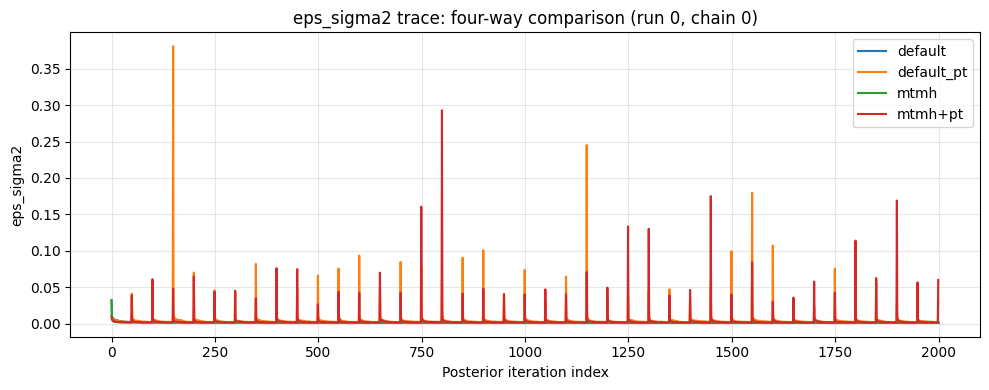

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
for key, _, _ in comparison_specs:
    ax.plot(comparison_sigma_traces[key], label=comparison_labels[key], color=comparison_colors[key])

ax.set_xlabel("Posterior iteration index")
ax.set_ylabel("eps_sigma2")
ax.set_title(f"eps_sigma2 trace: four-way comparison (run {int(selected_run['run_id'])}, chain {SELECT_CHAIN_ID})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

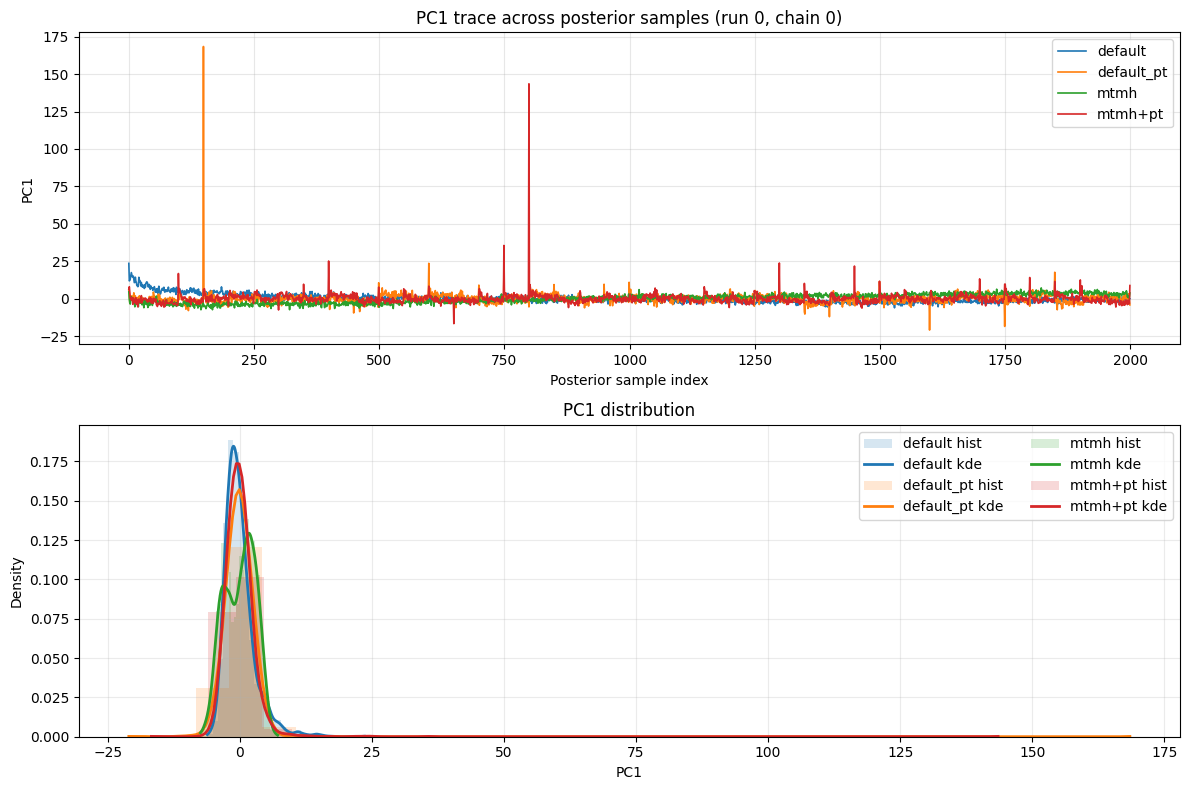

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for key, _, _ in comparison_specs:
    axes[0].plot(comparison_pc1[key], lw=1.2, label=comparison_labels[key], color=comparison_colors[key])

axes[0].set_title(f"PC1 trace across posterior samples (run {int(selected_run['run_id'])}, chain {SELECT_CHAIN_ID})")
axes[0].set_xlabel("Posterior sample index")
axes[0].set_ylabel("PC1")
axes[0].grid(alpha=0.3)
axes[0].legend()

for key, _, _ in comparison_specs:
    pc1 = comparison_pc1[key]
    axes[1].hist(pc1, bins=30, density=True, alpha=0.18, color=comparison_colors[key], label=f"{comparison_labels[key]} hist")
    x_grid = np.linspace(np.min(pc1), np.max(pc1), 300)
    kde = gaussian_kde(pc1)
    axes[1].plot(x_grid, kde(x_grid), color=comparison_colors[key], linewidth=2.0, label=f"{comparison_labels[key]} kde")

axes[1].set_title("PC1 distribution")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("Density")
axes[1].grid(alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()

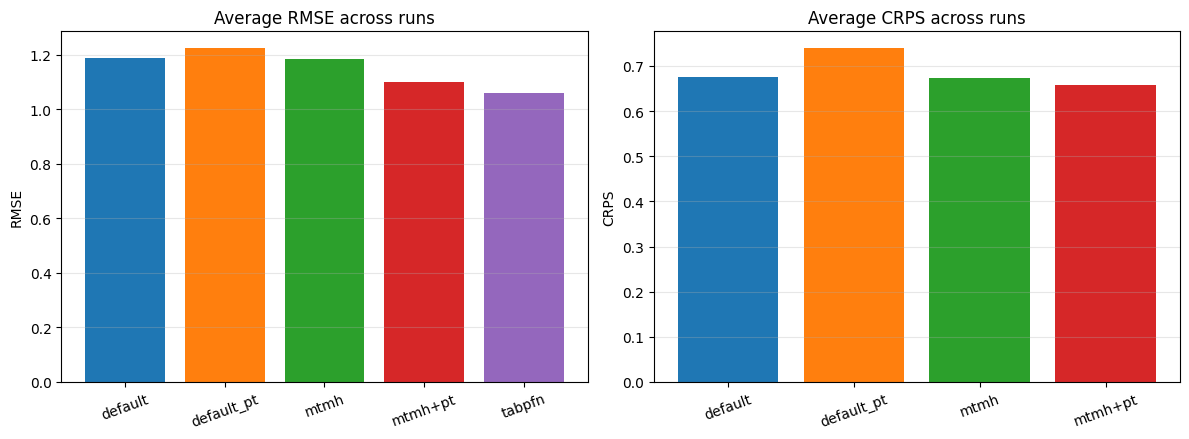

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rmse_means = rmse_table.mean(axis=0)
crps_means = crps_table.mean(axis=0)

axes[0].bar(rmse_means.index, rmse_means.values, color=[comparison_colors_by_label.get(label, "gray") for label in rmse_means.index])
axes[0].set_title("Average RMSE across runs")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(crps_means.index, crps_means.values, color=[comparison_colors_by_label.get(label, "gray") for label in crps_means.index])
axes[1].set_title("Average CRPS across runs")
axes[1].set_ylabel("CRPS")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

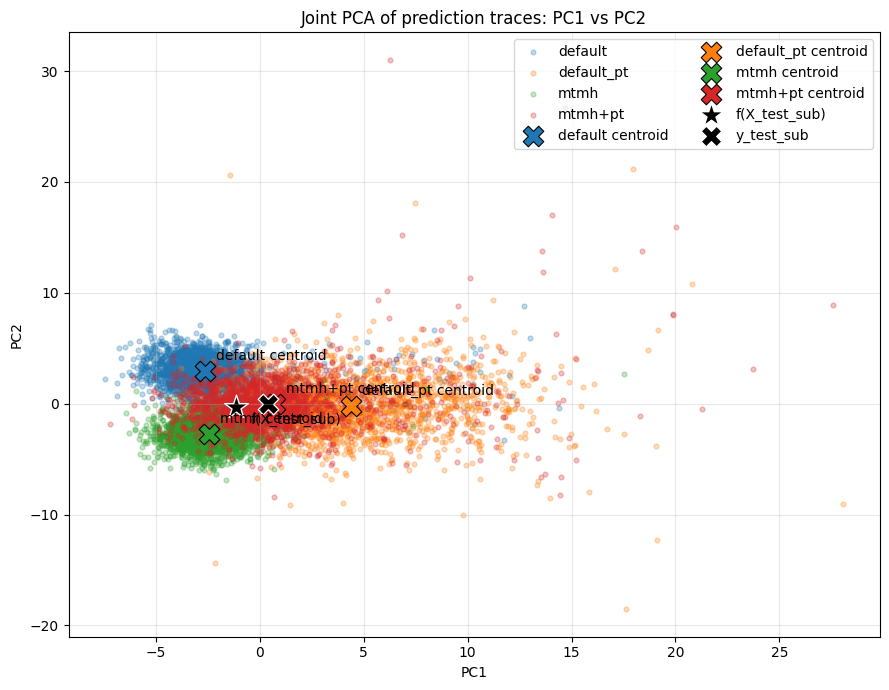

Explained variance ratio: [0.04922532 0.0237698 ]
default centroid: [-2.6316939   2.95043488]
default_pt centroid: [ 4.3603877  -0.16801149]
mtmh centroid: [-2.44286745 -2.75360769]
mtmh+pt centroid: [ 0.71417366 -0.0288157 ]


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

for key, label, _ in comparison_specs:
    coords = comparison_joint_coords[joint_labels == label]
    ax.scatter(coords[:, 0], coords[:, 1], s=12, alpha=0.28, label=label, color=comparison_colors[key])

for key, label, _ in comparison_specs:
    centroid = comparison_centroids[key]
    ax.scatter(
        centroid[0], centroid[1],
        s=220, marker="X", color=comparison_colors[key], edgecolor="black", linewidth=0.8,
        label=f"{label} centroid",
    )
    ax.annotate(
        f"{label} centroid",
        (centroid[0], centroid[1]),
        xytext=(8, 8),
        textcoords="offset points",
    )

f_test_point = (
    10.0 * np.sin(np.pi * selected_X_test[:, 0] * selected_X_test[:, 1])
    + 20.0 * (selected_X_test[:, 2] - 0.5) ** 2
    + 10.0 * selected_X_test[:, 3]
    + 5.0 * selected_X_test[:, 4]
)
f_test_coords = comparison_pca2.transform(f_test_point.reshape(1, -1))[0]
ax.scatter(
    f_test_coords[0], f_test_coords[1],
    s=320, marker="*", color="black", edgecolor="white", linewidth=1.0,
    label="f(X_test_sub)",
)
ax.scatter(
    y_test_coords[0], y_test_coords[1],
    s=220, marker="X", color=comparison_colors_by_label["y_test_sub"],
    edgecolor="white", linewidth=0.9, label="y_test_sub",
)
ax.annotate(
    "f(X_test_sub)",
    (f_test_coords[0], f_test_coords[1]),
    xytext=(10, -12),
    textcoords="offset points",
    color="black",
)

ax.set_title("Joint PCA of prediction traces: PC1 vs PC2")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", comparison_pca2.explained_variance_ratio_)
for key, label, _ in comparison_specs:
    print(f"{label} centroid:", comparison_centroids[key])